
**-----PROJEKT--GRUPP6-----** <br>
Pär Hedström<br>
Fredrik Domert Eriksson<br>
Rickard Andersson<br>

# Data Collection Spider<br>
Jag har gjort ett försök till att bygga en Spider som utför Web Scraping. Den simulerar en mänsklig användare för att hämta strukturerad data från en databas. Eller i det här fallet en webbsida. Jag har byggt den ganska generellt just med filter-valen, det kan vi ju ändra lite som vi vill sen när vi är överens. Men den fungerar bra. Den laddar ner en csv-fil i en mapp (data_folder) som skapas i den mapp där jupyter-filen ligger. När man kör koden så kommer hemsidan upp och sen tar det kanske 10 sek innan den skriver i sökfältet. /RA

In [2]:
# Använt kod från https://www.geeksforgeeks.org/web-scraping/scrape-linkedin-using-selenium-and-beautiful-soup-in-python/

# Installerar selenium för att kunna hantera knappar och menyer
%pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Importerar dom bibliotek vi behöver

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import Select
import time
import os

# --- KONFIGURATION & SÖKVÄGAR ---
SEARCH_TERM = "Avsiktligt självdestruktiv handling"
DATA_DIR = os.path.join(os.getcwd())

# Skapar en mapp om den inte redan finns
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

chrome_options = Options()
chrome_options.add_experimental_option("prefs", {
    "download.default_directory": DATA_DIR,
    "download.prompt_for_download": False,
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=chrome_options)
wait = WebDriverWait(driver, 20)

# Här startas sidan (socialstyrelsen) där man kan välja filter och använda sökfältet 
try:
    print(f"Startar sökning. Filer kommer sparas i: {DATA_DIR}")
    driver.get("https://sdb.socialstyrelsen.se/if_dor/val.aspx")

    print("Väljer månadsuppgifter...")
    # Det första vi vill göra är att välja månadsuppgifter då det ändrar filtreringen
    try:
        # Vi letar efter select-elementet inuti diven
        select_ar_manad = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div[id*='armanad_ind'] select"))) # Div-element för År/månadsuppgifter
        s_typer = Select(select_ar_manad)
        s_typer.select_by_visible_text("Månadsuppgifter")
        
        # Trigga sidans eget skript för att rita om gränssnittet till månadsvisning
        driver.execute_script("arguments[0].onchange();", select_ar_manad)
    except Exception as e:
        # Om select-logiken inte fungerar
        print("Kör reservmetod för månadsuppgifter...")
        driver.execute_script("document.querySelector(\"div[id*='armanad_ind'] select\").value = 'm';")
    time.sleep(2.5)

    # Om det ligger gamla val eller text i sökfält så rensas det
    print("Nollställer tidigare val...")
    try:
        rensa = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_dia_id_btnRensaValda"))) # html-element för rensning av val
        driver.execute_script("arguments[0].click();", rensa)
    except:
        pass

    # Använder sökfältet
    print(f"Söker efter: '{SEARCH_TERM}'...")
    sok_falt = wait.until(EC.element_to_be_clickable((By.ID, "Sokord"))) # html-element för sökfält
    sok_falt.clear()
    sok_falt.send_keys(SEARCH_TERM)
    sok_falt.send_keys(Keys.ENTER)

    # Bockar i rutor för sökresultat
    # Har lagt ut några print då det krånglade en del så jag kunde se vart det tog stopp
    print("Markerar diagnosrutor...")
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']"))) # html-element för checkbox sök-resultat
    checkboxar = driver.find_elements(By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']")
    for cb in checkboxar:
        if not cb.is_selected():
            driver.execute_script("arguments[0].click();", cb)
    
    # Filter för Ålder, Kön och månad där vi bockar i Välj alla
    print("Väljer filter...")
    time.sleep(1)
    knappar_att_klicka = [
        "ph1_val_kon_id_hlAdd",    # Välj alla för Kön
        "ph1_val_ar_id_hlAdd",     # Välj alla för År
        "ph1_val_manad_id_hlAdd"   # Välj alla för Månad
    ]
    
    for knap_id in knappar_att_klicka:
        try:
            knapp = driver.find_element(By.ID, knap_id)
            driver.execute_script("arguments[0].click();", knapp)
            time.sleep(0.1)
        except Exception as e:
            print(f"Kunde inte klicka på filter {knap_id}: {e}")

    # Letar upp knappen för Visa resultat
    # Generera tabell och hämta CSV
    print("Genererar tabell...")
    try:
        # Kör javascript-funktionen direkt
        driver.execute_script("submitResultat();")
    except:
        # Backup om JS-anropet krånglar
        visa_lank = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_data_id_lnkVisaResultat"))) # html-element
        driver.execute_script("arguments[0].click();", visa_lank)

    # Nu har vi kommit till resultat-sidan av vår sökning.
    # Högst upp till höger letar vi på csv-länken som laddar ner filen till vår mapp.
    print("Hämtar CSV-fil...")
    csv_knapp = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "a[id$='lbCSV']")))
    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", csv_knapp)
    time.sleep(0.5)
    csv_knapp.click()
    
    print(f"KLART! Din data ligger nu i din mapp.")
    time.sleep(2) # Tid för Chrome då det gick lite för fort tidigare

except Exception as e:
    print(f"Ett fel uppstod: {e}")

# Stänger ner sidan när allt är klart
finally:
    # Vi kollar om driver existerar innan vi försöker stänga den
    if 'driver' in locals() or 'driver' in globals():
        try:
            driver.close() # Stänger fliken
            driver.quit()  # Stänger hela programmet
            print("Webbläsaren stängdes korrekt.")
        except:
            pass # Om den redan var stängd gör vi ingenting

Startar sökning. Filer kommer sparas i: c:\Users\Rickard\OneDrive\Dokument\GitHub\projekt-grupp6
Väljer månadsuppgifter...
Kör reservmetod för månadsuppgifter...
Nollställer tidigare val...
Söker efter: 'Avsiktligt självdestruktiv handling'...
Markerar diagnosrutor...
Väljer filter...
Genererar tabell...
Hämtar CSV-fil...
KLART! Din data ligger nu i din mapp.
Webbläsaren stängdes korrekt.


# Data-Analys pre-processing

In [ ]:
import pandas as pd
import numpy as np

# Vi laddar in den nedladdade filen och kollar på dess struktur för att kunna rensa den ordentligt
file_name = os.path.join("Statistikdatabasen_2026-05-28 12_03_45.csv")
try:
    df = pd.read_csv(file_name, sep=';', encoding='utf-8')
    print("--- HEAD ---") 
    print(df.head(15))
    print("\n--- INFO ---")
    print(df.info())
except Exception as e:
    print(f"Error reading with utf-8: {e}")
    # Om det inte fungerar att läsa med utf-8 så försöker vi med latin1 som är vanligt för svenska tecken
    try:
        df = pd.read_csv(file_name, sep=';', encoding='latin1')
        print("--- HEAD ---")
        print(df.head(15))
        print("\n--- INFO ---")
        print(df.info())
    except Exception as e2:
        print(f"Error reading with latin1: {e2}")

--- HEAD ---
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [ ]:

# Om det ser ut som att det är en extra rad i början som inte är header så kan vi testa att hoppa över den raden
df = pd.read_csv(file_name, sep=';', encoding='latin1', header=0)

print("Original columns snippet:", list(df.columns[:5]))
print("Original index column content:\n", df.iloc[:, 0])

# Den första raden innehåller faktiskt rubriketiketterna om vi hoppar över titelraden eller åtgärdar den.
# Låt oss ladda om genom att hoppa över valfri titel om det behövs, eller åtgärda kolumner.
# Låt oss se formen.
print("Shape:", df.shape)

Original columns snippet: ['ï»¿DÃ¶dsorsaksstatistik, Antal dÃ¶da, X60-X84 Avsiktligt sjÃ¤lvdestruktiv handling, Riket, Ã\x85lder: 0-95+']
Original index column content:
 KÃ¶n                                          Januari 1997  Februari 1997  Mars 1997  April 1997  Maj 1997  Juni 1997  Juli 1997  Augusti 1997  September 1997  Oktober 1997  November 1997  December 1997  Januari 1998  Februari 1998  Mars 1998  April 1998  Maj 1998  Juni 1998  Juli 1998  Augusti 1998  September 1998  Oktober 1998  November 1998  December 1998  Januari 1999  Februari 1999  Mars 1999  April 1999  Maj 1999  Juni 1999  Juli 1999  Augusti 1999  September 1999  Oktober 1999  November 1999  December 1999  Januari 2000  Februari 2000  Mars 2000  April 2000  Maj 2000  Juni 2000  Juli 2000  Augusti 2000  September 2000  Oktober 2000  November 2000  December 2000  Januari 2001  Februari 2001  Mars 2001  April 2001  Maj 2001  Juni 2001  Juli 2001  Augusti 2001  September 2001  Oktober 2001  November 2001  December 

In [ ]:
# Vi kikar på hur en rådatafil ser ut innan vi börjar städa den

with open("Statistikdatabasen_2026-05-28 12_03_45.csv", "r", encoding="latin1") as f:
    for i in range(15):
        print(f.readline()[:200])

ï»¿DÃ¶dsorsaksstatistik, Antal dÃ¶da, X60-X84 Avsiktligt sjÃ¤lvdestruktiv handling, Riket, Ãlder: 0-95+

KÃ¶n;Januari 1997;Februari 1997;Mars 1997;April 1997;Maj 1997;Juni 1997;Juli 1997;Augusti 1997;September 1997;Oktober 1997;November 1997;December 1997;Januari 1998;Februari 1998;Mars 1998;April 1998;M
MÃ¤n;82;70;73;67;74;75;72;82;54;57;65;57;79;50;75;71;96;68;78;75;64;68;67;68;52;62;56;71;65;88;72;81;71;69;70;76;66;63;68;51;72;67;59;69;55;69;80;59;71;49;68;63;87;69;74;81;58;77;48;60;72;51;70;78;77;
Kvinnor;22;29;40;26;27;32;24;32;24;32;22;22;29;19;30;26;36;26;33;35;30;36;23;21;32;16;24;23;32;31;28;37;25;38;29;29;17;28;32;26;32;22;27;38;18;26;25;27;31;28;27;40;29;20;25;26;34;27;33;33;21;23;31;36;
BÃ¥da kÃ¶nen;104;99;113;93;101;107;96;114;78;89;87;79;108;69;105;97;132;94;111;110;94;104;90;89;84;78;80;94;97;119;100;118;96;107;99;105;83;91;100;77;104;89;86;107;73;95;105;86;102;77;95;103;116;89;99
Socialstyrelsens statistikdatabas 2026-05-28











In [ ]:
# Efter att ha inspekterat filen så verkar det som att den har två rader i början 
# som inte är en del av datatabellen, utan mer metadata eller titel. 
# Den riktiga headern verkar börja på rad 3 (index 2). 
# Vi kan därför ladda om filen och hoppa över de första två raderna för att få en korrekt DataFrame.
df = pd.read_csv("Statistikdatabasen_2026-05-28 12_03_45.csv", sep=';', encoding='latin1', header=2)
print("Shape:", df.shape)
print("Columns snippet:", list(df.columns[:5]))
print("Head:\n", df)

Shape: (3, 351)
Columns snippet: ['MÃ¤n', '82', '70', '73', '67']
Head:
                                            MÃ¤n     82    70     73    67  \
0                                       Kvinnor   22.0  29.0   40.0  26.0   
1                                  BÃ¥da kÃ¶nen  104.0  99.0  113.0  93.0   
2  Socialstyrelsens statistikdatabas 2026-05-28    NaN   NaN    NaN   NaN   

      74     75    72   82.1    54  ...  75.12  53.2   80.9   89.1  70.10  \
0   27.0   32.0  24.0   32.0  24.0  ...   15.0  24.0   37.0   34.0   34.0   
1  101.0  107.0  96.0  114.0  78.0  ...   90.0  77.0  117.0  123.0  104.0   
2    NaN    NaN   NaN    NaN   NaN  ...    NaN   NaN    NaN    NaN    NaN   

   65.21  Â­Â­  Â­Â­.1  Â­Â­.2  Â­Â­.3  
0   28.0  Â­Â­    Â­Â­    Â­Â­    Â­Â­  
1   93.0  Â­Â­    Â­Â­    Â­Â­    Â­Â­  
2    NaN   NaN     NaN     NaN     NaN  

[3 rows x 351 columns]


In [ ]:
# Nu när vi vet att det är två rader i början som inte är data så kan vi också använda skiprows 
# för att hoppa över dem istället för att använda header=2
df = pd.read_csv("Statistikdatabasen_2026-05-28 12_03_45.csv", sep=';', encoding='latin1', skiprows=2)
print("Shape:", df.shape)
print("Columns snippet:", list(df.columns[:5]))
print("Head:\n", df)

Shape: (3, 351)
Columns snippet: ['MÃ¤n', '82', '70', '73', '67']
Head:
                                            MÃ¤n     82    70     73    67  \
0                                       Kvinnor   22.0  29.0   40.0  26.0   
1                                  BÃ¥da kÃ¶nen  104.0  99.0  113.0  93.0   
2  Socialstyrelsens statistikdatabas 2026-05-28    NaN   NaN    NaN   NaN   

      74     75    72   82.1    54  ...  75.12  53.2   80.9   89.1  70.10  \
0   27.0   32.0  24.0   32.0  24.0  ...   15.0  24.0   37.0   34.0   34.0   
1  101.0  107.0  96.0  114.0  78.0  ...   90.0  77.0  117.0  123.0  104.0   
2    NaN    NaN   NaN    NaN   NaN  ...    NaN   NaN    NaN    NaN    NaN   

   65.21  Â­Â­  Â­Â­.1  Â­Â­.2  Â­Â­.3  
0   28.0  Â­Â­    Â­Â­    Â­Â­    Â­Â­  
1   93.0  Â­Â­    Â­Â­    Â­Â­    Â­Â­  
2    NaN   NaN     NaN     NaN     NaN  

[3 rows x 351 columns]


In [ ]:
# Vi kikar på hur en rådatafil ser ut nu när vi vet att det är två rader i början som inte är data så kan vi också använda skiprows
with open("Statistikdatabasen_2026-05-28 12_03_45.csv", "r", encoding="latin1") as f:
    lines = [f.readline().strip() for _ in range(5)]
for idx, line in enumerate(lines):
    print(f"Line {idx}: {line[:100]}")

Line 0: ï»¿DÃ¶dsorsaksstatistik, Antal dÃ¶da, X60-X84 Avsiktligt sjÃ¤lvdestruktiv handling, Riket, Ãlder: 0
Line 1: KÃ¶n;Januari 1997;Februari 1997;Mars 1997;April 1997;Maj 1997;Juni 1997;Juli 1997;Augusti 1997;Septe
Line 2: MÃ¤n;82;70;73;67;74;75;72;82;54;57;65;57;79;50;75;71;96;68;78;75;64;68;67;68;52;62;56;71;65;88;72;81
Line 3: Kvinnor;22;29;40;26;27;32;24;32;24;32;22;22;29;19;30;26;36;26;33;35;30;36;23;21;32;16;24;23;32;31;28
Line 4: BÃ¥da kÃ¶nen;104;99;113;93;101;107;96;114;78;89;87;79;108;69;105;97;132;94;111;110;94;104;90;89;84;7


In [ ]:
# Vi testar att läsa in filen igen med skiprows=1 för att se om det ger en bättre struktur
df = pd.read_csv("Statistikdatabasen_2026-05-28 12_03_45.csv", sep=';', encoding='latin1', skiprows=1)
print("Shape:", df.shape)
print("Columns snippet:", list(df.columns[:5]))
print("Head:\n", df)

Shape: (4, 351)
Columns snippet: ['KÃ¶n', 'Januari 1997', 'Februari 1997', 'Mars 1997', 'April 1997']
Head:
                                            KÃ¶n  Januari 1997  Februari 1997  \
0                                          MÃ¤n          82.0           70.0   
1                                       Kvinnor          22.0           29.0   
2                                  BÃ¥da kÃ¶nen         104.0           99.0   
3  Socialstyrelsens statistikdatabas 2026-05-28           NaN            NaN   

   Mars 1997  April 1997  Maj 1997  Juni 1997  Juli 1997  Augusti 1997  \
0       73.0        67.0      74.0       75.0       72.0          82.0   
1       40.0        26.0      27.0       32.0       24.0          32.0   
2      113.0        93.0     101.0      107.0       96.0         114.0   
3        NaN         NaN       NaN        NaN        NaN           NaN   

   September 1997  ...  Maj 2025  Juni 2025  Juli 2025  Augusti 2025  \
0            54.0  ...      75.0       53.0    

In [ ]:
# Nu när vi har en korrekt DataFrame så kan vi börja rensa den ordentligt. Vi ser att det finns tre rader
df_clean = df.iloc[:3].copy() # Spara bara Män, Kvinnor, Båda könen
df_clean = df_clean.rename(columns={'KÃ¶n': 'Gender'})
df_clean['Gender'] = df_clean['Gender'].map({'MÃ¤n': 'Män', 'Kvinnor': 'Kvinnor', 'BÃ¥da kÃ¶nen': 'Båda könen'})

# Smält dataframen
df_long = df_clean.melt(id_vars=['Gender'], var_name='Month_Year', value_name='Deaths')

print(df_long.head(10))
print("\nUnique values in Deaths column (samples):", df_long['Deaths'].unique()[:10])
print("\nMissing values representation:", df_long[df_long['Deaths'].isna() | (df_long['Deaths'] == '­­') | (df_long['Deaths'].astype(str).str.contains('­'))].head())

       Gender     Month_Year Deaths
0         Män   Januari 1997   82.0
1     Kvinnor   Januari 1997   22.0
2  Båda könen   Januari 1997  104.0
3         Män  Februari 1997   70.0
4     Kvinnor  Februari 1997   29.0
5  Båda könen  Februari 1997   99.0
6         Män      Mars 1997   73.0
7     Kvinnor      Mars 1997   40.0
8  Båda könen      Mars 1997  113.0
9         Män     April 1997   67.0

Unique values in Deaths column (samples): [82.0 22.0 104.0 70.0 29.0 99.0 73.0 40.0 113.0 67.0]

Missing values representation:           Gender     Month_Year Deaths
1038         Män  November 2025   Â­Â­
1039     Kvinnor  November 2025   Â­Â­
1040  Båda könen  November 2025   Â­Â­
1041         Män  December 2025   Â­Â­
1042     Kvinnor  December 2025   Â­Â­


In [ ]:
# Vi kollar vilka kolumner som finns för 2026 och 2025 för att se hur de är namngivna
cols_2026 = [c for c in df.columns if '2026' in c]
print("2026 columns:", cols_2026)
cols_2025 = [c for c in df.columns if '2025' in c]
print("2025 columns:", cols_2025)

2026 columns: ['Januari 2026', 'Februari 2026']
2025 columns: ['Januari 2025', 'Februari 2025', 'Mars 2025', 'April 2025', 'Maj 2025', 'Juni 2025', 'Juli 2025', 'Augusti 2025', 'September 2025', 'Oktober 2025', 'November 2025', 'December 2025']


In [ ]:
# Skapar en mapping för månader och säsonger
month_mapping = {
    'Januari': {'num': 1, 'season': 'Vinter'},
    'Februari': {'num': 2, 'season': 'Vinter'},
    'Mars': {'num': 3, 'season': 'Vår'},
    'April': {'num': 4, 'season': 'Vår'},
    'Maj': {'num': 5, 'season': 'Vår'},
    'Juni': {'num': 6, 'season': 'Sommar'},
    'Juli': {'num': 7, 'season': 'Sommar'},
    'Augusti': {'num': 8, 'season': 'Sommar'},
    'September': {'num': 9, 'season': 'Höst'},
    'Oktober': {'num': 10, 'season': 'Höst'},
    'November': {'num': 11, 'season': 'Höst'},
    'December': {'num': 12, 'season': 'Vinter'}
}

# Splitta Month_Year i separata kolumner för Månad och År, och konvertera År till numeriskt
df_long[['Månad', 'År']] = df_long['Month_Year'].str.split(' ', expand=True)
df_long['År'] = pd.to_numeric(df_long['År'])

# Lägg till Månad_Nummer och Säsong baserat på Månad
df_long['Månad_Nummer'] = df_long['Månad'].map(lambda x: month_mapping.get(x, {}).get('num', np.nan))
df_long['Säsong'] = df_long['Månad'].map(lambda x: month_mapping.get(x, {}).get('season', 'Okänd'))

# Rensa 'Deaths' kolumnen genom att ta bort oönskade tecken och 
# konvertera till numeriskt, hantera även olika representationer av saknade värden
def clean_deaths(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if 'Â' in s or '­' in s or s == '' or s.startswith('Â'):
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

df_long['Antal_Döda'] = df_long['Deaths'].apply(clean_deaths)

# Sortera dataframen för bättre översikt
df_long = df_long.sort_values(by=['Gender', 'År', 'Månad_Nummer']).reset_index(drop=True)

# Spara till CSV
cleaned_file = "Socialstyrelsen_Cleaned_Long.csv"
df_long[['Gender', 'År', 'Månad', 'Månad_Nummer', 'Säsong', 'Antal_Döda']].to_csv(cleaned_file, index=False, sep=';', encoding='utf-8')

print("Cleaned preview:")
print(df_long[['Gender', 'År', 'Månad', 'Säsong', 'Antal_Döda']].dropna().head(12))
print("\nShape after cleaning:", df_long.shape)

Cleaned preview:
        Gender    År      Månad  Säsong  Antal_Döda
0   Båda könen  1997    Januari  Vinter       104.0
1   Båda könen  1997   Februari  Vinter        99.0
2   Båda könen  1997       Mars     Vår       113.0
3   Båda könen  1997      April     Vår        93.0
4   Båda könen  1997        Maj     Vår       101.0
5   Båda könen  1997       Juni  Sommar       107.0
6   Båda könen  1997       Juli  Sommar        96.0
7   Båda könen  1997    Augusti  Sommar       114.0
8   Båda könen  1997  September    Höst        78.0
9   Båda könen  1997    Oktober    Höst        89.0
10  Båda könen  1997   November    Höst        87.0
11  Båda könen  1997   December  Vinter        79.0

Shape after cleaning: (1050, 8)


# Visualisering

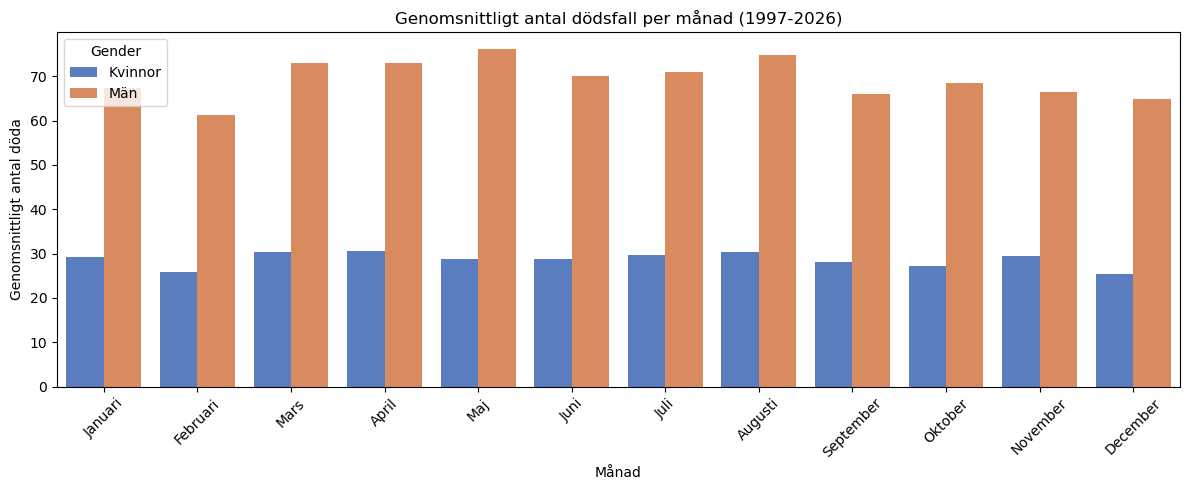

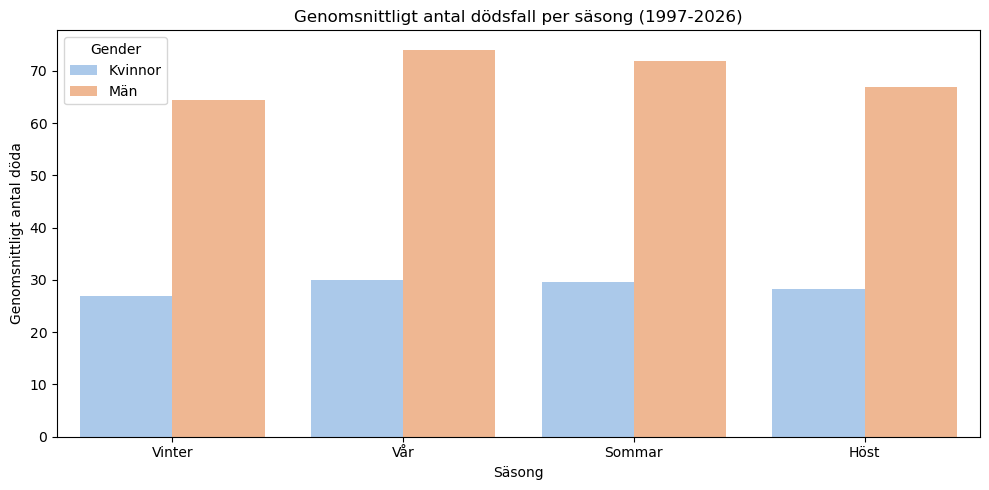

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Läs in den städade filen som vi rensat
df = pd.read_csv("Socialstyrelsen_Cleaned_Long.csv", sep=";")

# Filtrera bort "Båda könen" så vi kan jämföra Män och Kvinnor direkt
df_kön = df[df['Gender'] != 'Båda könen'].dropna()

# Sortera månaderna korrekt chronologiskt
manad_ordning = ["Januari", "Februari", "Mars", "April", "Maj", "Juni", 
                 "Juli", "Augusti", "September", "Oktober", "November", "December"]
sasong_ordning = ["Vinter", "Vår", "Sommar", "Höst"]

# --- VISUALISERING 1: Per Månad ---
plt.figure(figsize=(12, 5))
sns.barplot(data=df_kön, x='Månad', y='Antal_Döda', hue='Gender', order=manad_ordning, errorbar=None, palette="muted")
plt.title("Genomsnittligt antal dödsfall per månad (1997-2026)")
plt.ylabel("Genomsnittligt antal döda")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("suicide_per_month.png")
plt.show()

# --- VISUALISERING 2: Per Säsong ---
plt.figure(figsize=(10, 5))
sns.barplot(data=df_kön, x='Säsong', y='Antal_Döda', hue='Gender', order=sasong_ordning, errorbar=None, palette="pastel")
plt.title("Genomsnittligt antal dödsfall per säsong (1997-2026)")
plt.ylabel("Genomsnittligt antal döda")
plt.tight_layout()
plt.savefig("suicide_per_season.png")
plt.show()

<Figure size 1200x1000 with 0 Axes>

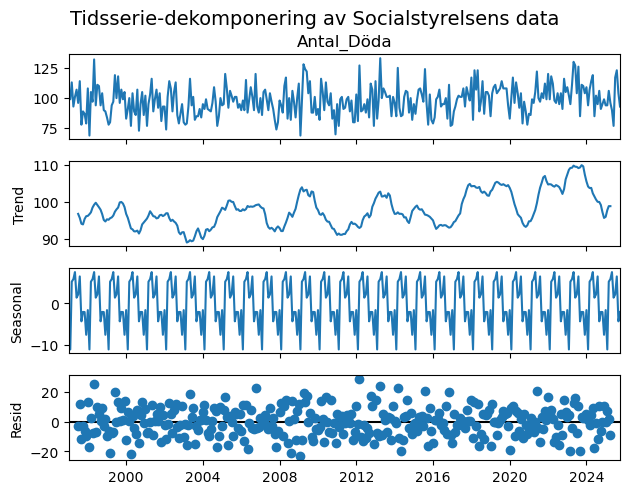

In [ ]:
# Kod från https://www.geeksforgeeks.org/machine-learning/time-series-analysis-and-forecasting/

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Läs in datan
df = pd.read_csv("Socialstyrelsen_Cleaned_Long.csv", sep=";")

# Filtrera ut "Båda könen" för en övergripande analys och ta bort eventuella tomma rader
df_total = df[df['Gender'] == 'Båda könen'].dropna().copy()

# Skapa en riktig datetime-kolumn som modeller förstår (t.ex. "1997-01-01")
# Vi mappar månadnummer till ett standardformat
df_total['Datum'] = pd.to_datetime(df_total['År'].astype(str) + '-' + df_total['Månad_Nummer'].astype(str) + '-01')

# Sätt datumet som index och sortera chronologiskt
df_total = df_total.set_index('Datum').sort_index()

# Vi behåller bara tidsserien (Antal döda)
ts = df_total['Antal_Döda']

# --- IMPLEMENTATION AV GEEKSFORGEEKS: DECOMPOSITION ---
# Vi sätter period=12 eftersom det är månadsdata (12 månader på ett år)
result = seasonal_decompose(ts, model='additive', period=12)

# Rita upp diagrammet
plt.figure(figsize=(12, 10))
result.plot()
plt.suptitle('Tidsserie-dekomponering av Socialstyrelsens data', y=1.02, fontsize=14)
plt.savefig("time_series_decomposition.png")
plt.show()

Läser in den färdigstädade filen: Socialstyrelsen_Cleaned_Long.csv

--- PREVIEW AV PROGNOSDATA ---
              År  Månad_Nummer    Forecast
Datum                                     
2025-11-01  2025            11   99.863499
2025-12-01  2025            12   94.327785
2026-01-01  2026             1  100.664211
2026-02-01  2026             2   91.388349
2026-03-01  2026             3  107.664211
2026-04-01  2026             4  107.629728
2026-05-01  2026             5  108.974555
2026-06-01  2026             6  103.043521
2026-07-01  2026             7  104.871107
2026-08-01  2026             8  109.250417


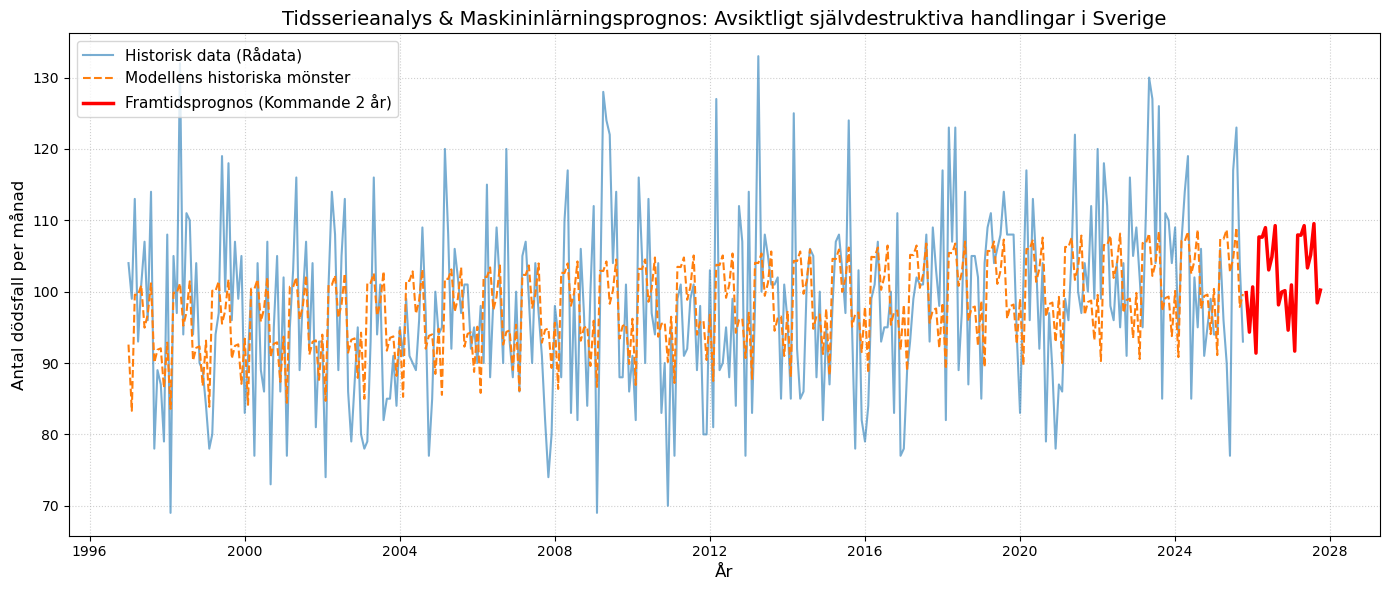

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =====================================================================
#                 LÄS IN DEN REDAN STÄDADE DATAN
# =====================================================================
# Vi använder filen som redan har rätt struktur
file_name = "Socialstyrelsen_Cleaned_Long.csv"
print(f"Läser in den färdigstädade filen: {file_name}")

df_long = pd.read_csv(file_name, sep=";")

# Sortera datan kronologiskt och välj det totala antalet (Båda könen)
df_total = df_long[df_long['Gender'] == 'Båda könen'].dropna().copy()
df_total = df_total.sort_values(by=['År', 'Månad_Nummer']).reset_index(drop=True)

# =====================================================================
#                       FEATURE ENGINEERING
# =====================================================================
# Skapar en trendaxel: 0, 1, 2, 3... representerar tidens gång månad för månad
df_total['Time_Step'] = np.arange(len(df_total))

# Skapar säsongs-dummies (One-Hot Encoding för månaderna 1-12)
for m in range(1, 13):
    df_total[f'Month_{m}'] = (df_total['Månad_Nummer'] == m).astype(int)

# Definiera x (funktioner) och y (målet vi vill förutsäga)
feature_cols = ['Time_Step'] + [f'Month_{m}' for m in range(1, 13)]
X = df_total[feature_cols]
y = df_total['Antal_Döda']

# =====================================================================
#        TRÄNA MASKININLÄRNINGSMODELLEN (LINEAR REGRESSION)
# =====================================================================
model = LinearRegression()
model.fit(X, y)

# Gör historiska förutsägelser (in-sample prediction)
df_total['Fitted_Values'] = model.predict(X)

# =====================================================================
#          SKAPA PROGNOS 24 MÅNADER FRAMÅT (FORECASTING)
# =====================================================================
future_months = 24
last_step = df_total['Time_Step'].max()
last_year = df_total['År'].max()
last_month = df_total.loc[df_total['Time_Step'] == last_step, 'Månad_Nummer'].values[0]

future_records = []
current_step = last_step + 1
current_year = last_year
current_month = last_month

for i in range(future_months):
    current_month += 1
    if current_month > 12:
        current_month = 1
        current_year += 1
    
    row = {'Time_Step': current_step, 'År': current_year, 'Månad_Nummer': current_month}
    for m in range(1, 13):
        row[f'Month_{m}'] = 1 if current_month == m else 0
    future_records.append(row)
    current_step += 1

df_future = pd.DataFrame(future_records)
df_future['Forecast'] = model.predict(df_future[feature_cols])

# Skapa datum-index för snyggare grafer
df_total['Datum'] = pd.to_datetime(df_total['År'].astype(str) + '-' + df_total['Månad_Nummer'].astype(str) + '-01')
df_total = df_total.set_index('Datum')

future_dates = pd.date_range(start=df_total.index[-1] + pd.DateOffset(months=1), periods=future_months, freq='MS')
df_future['Datum'] = future_dates
df_future = df_future.set_index('Datum')

print("\n--- PREVIEW AV PROGNOSDATA ---")
print(df_future[['År', 'Månad_Nummer', 'Forecast']].head(10))

# =====================================================================
#           SKAPA OCH SPARA DIAGRAMMET (VISUALISERING)
# =====================================================================
plt.figure(figsize=(14, 6))

# Rita den historiska datan
plt.plot(df_total.index, df_total['Antal_Döda'], label='Historisk data (Rådata)', color='#1f77b4', alpha=0.6)
# Rita modellens anpassning över historien
plt.plot(df_total.index, df_total['Fitted_Values'], label='Modellens historiska mönster', color='#ff7f0e', linestyle='--')
# Rita framtidsprognosen
plt.plot(df_future.index, df_future['Forecast'], label='Framtidsprognos (Kommande 2 år)', color='red', linewidth=2.5)

plt.title("Tidsserieanalys & Maskininlärningsprognos: Avsiktligt självdestruktiva handlingar i Sverige", fontsize=14)
plt.xlabel("År", fontsize=12)
plt.ylabel("Antal dödsfall per månad", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.savefig("tidsserie_prognos_ml.png", dpi=300)
plt.show()

# Affine Transformation

Båda kriserna har transformerats geometriskt och flyttats till år 2027!


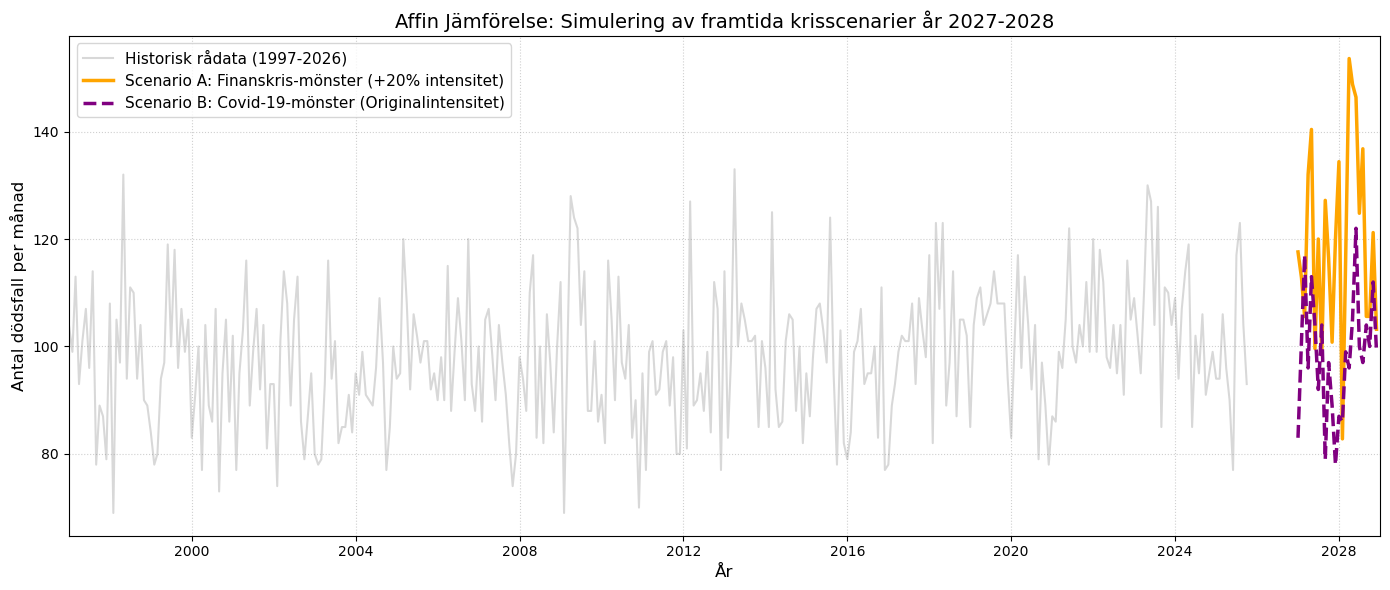

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
#                    LÄS IN OCH JSTÄDA DATAN
# =====================================================================

# Använder vår redan städade fil som har rätt struktur och kolumner
file_name = "Socialstyrelsen_Cleaned_Long.csv"
df_long = pd.read_csv(file_name, sep=";")

df_total = df_long[df_long['Gender'] == 'Båda könen'].dropna().copy()
df_total = df_total.sort_values(by=['År', 'Månad_Nummer']).reset_index(drop=True)

# Skapa datetime-index
df_total['Datum'] = pd.to_datetime(df_total['År'].astype(str) + '-' + df_total['Månad_Nummer'].astype(str) + '-01')
df_total = df_total.set_index('Datum')

# =====================================================================
#                      AFFINE TRANSFORMATION
# =====================================================================
# Vi klipper ut 24 månader för varje kris
original_finans = df_total.loc['2008-01-01':'2009-12-01'].copy()
original_covid = df_total.loc['2020-01-01':'2021-12-01'].copy()

# Vi bestämmer en gemensam startpunkt i framtiden för simuleringen
framtida_start = pd.to_datetime('2027-01-01')
framtida_tidsaxel = pd.date_range(start=framtida_start, periods=24, freq='MS')

# --- Transformation 1: Finanskrisen ---
# Vi flyttar den till 2027 och skalar upp antalet döda med 20% (+20% intensitet)
kris_finans_trans = pd.DataFrame(index=framtida_tidsaxel)
kris_finans_trans['Antal_Döda'] = original_finans['Antal_Döda'].values * 1.20

# --- Transformation 2: Covid-19 ---
# Vi flyttar den till 2027 och behåller originalskalan (1.00) för att se den som den var
kris_covid_trans = pd.DataFrame(index=framtida_tidsaxel)
kris_covid_trans['Antal_Döda'] = original_covid['Antal_Döda'].values * 1.00

print("Båda kriserna har transformerats geometriskt och flyttats till år 2027!")

# =====================================================================
#                  VISUALISERING AV JÄMFÖRELSEN
# =====================================================================
plt.figure(figsize=(14, 6))

# Rita ut den historiska bakgrundsdatan (tonad i bakgrunden)
plt.plot(df_total.index, df_total['Antal_Döda'], label='Historisk rådata (1997-2026)', color='gray', alpha=0.3)

# Rita ut den transformerade finanskrisen i framtiden
plt.plot(kris_finans_trans.index, kris_finans_trans['Antal_Döda'], 
         color='orange', linewidth=2.5, linestyle='-', 
         label='Scenario A: Finanskris-mönster (+20% intensitet)')

# Rita ut det transformerade covid-mönstret på EXAKT samma tidslinje
plt.plot(kris_covid_trans.index, kris_covid_trans['Antal_Döda'], 
         color='purple', linewidth=2.5, linestyle='--', 
         label='Scenario B: Covid-19-mönster (Originalintensitet)')

# Designa diagrammet
plt.title("Affin Jämförelse: Simulering av framtida krisscenarier år 2027-2028", fontsize=14)
plt.xlabel("År", fontsize=12)
plt.ylabel("Antal dödsfall per månad", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

# Snygga till x-axeln så vi ser månaderna tydligt i framtidsdelen
plt.xlim(pd.to_datetime('1997-01-01'), pd.to_datetime('2029-01-01'))

plt.tight_layout()
plt.savefig("affine_transformation_dubbel_kris.png", dpi=300)
plt.show()

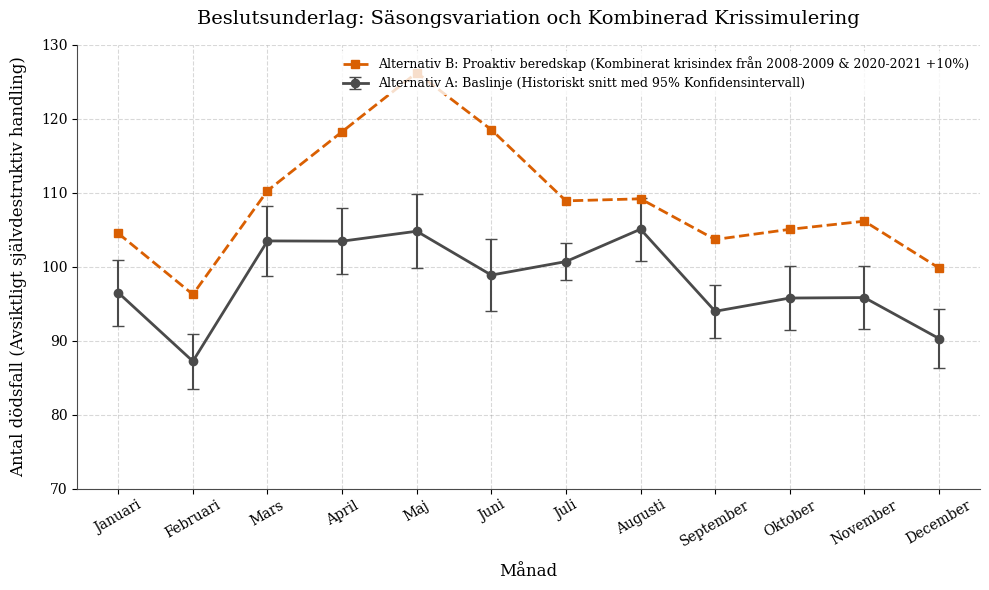


=== STATISTIK FÖR RAPPORT OCH VIDEO ===
Baserat på 29 års historik (Alternativ A) kontra sammanslagna krisår (Alternativ B)
Januari: Baslinje = 96.5 (±4.5) | Worst-Case Scenario = 104.5
Februari: Baslinje = 87.2 (±3.7) | Worst-Case Scenario = 96.3
Mars: Baslinje = 103.5 (±4.8) | Worst-Case Scenario = 110.3
April: Baslinje = 103.4 (±4.5) | Worst-Case Scenario = 118.3
Maj: Baslinje = 104.8 (±5.0) | Worst-Case Scenario = 126.2
Juni: Baslinje = 98.9 (±4.9) | Worst-Case Scenario = 118.5
Juli: Baslinje = 100.7 (±2.4) | Worst-Case Scenario = 108.9
Augusti: Baslinje = 105.1 (±4.3) | Worst-Case Scenario = 109.2
September: Baslinje = 94.0 (±3.6) | Worst-Case Scenario = 103.7
Oktober: Baslinje = 95.8 (±4.3) | Worst-Case Scenario = 105.1
November: Baslinje = 95.8 (±4.3) | Worst-Case Scenario = 106.2
December: Baslinje = 90.3 (±4.0) | Worst-Case Scenario = 99.8


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# =====================================================================
#     INLÄSNING OCH RESTRUKTURERING (DATA COLLECTION & ANALYSIS)
# =====================================================================
file_name = "Socialstyrelsen_Cleaned_Long.csv"
df_long = pd.read_csv(file_name, sep=";")

# Vi fokuserar på det totala antalet (Båda könen) för beslutsfattaren
df_total = df_long[df_long['Gender'] == 'Båda könen'].dropna().copy()

# =====================================================================
#      STATISTISK VERIFIERING: KONFIDENSINTERVALL PER MÅNAD
# =====================================================================
# Vi grupperar data per månad över alla år (1997-2024) för att hitta det "normala" mönstret
manads_stats = df_total.groupby('Månad_Nummer')['Antal_Döda'].agg(['mean', 'count', 'std']).copy()

# Räkna ut 95% konfidensintervall (Margin of Error) för varje månad
confidence_level = 0.95
manads_stats['error'] = manads_stats.apply(
    lambda row: stats.t.ppf((1 + confidence_level) / 2, row['count'] - 1) * (row['std'] / np.sqrt(row['count'])), 
    axis=1
)

# Sortera månaderna kronologiskt (Januari till December)
manads_stats = manads_stats.sort_index()
manads_namn = ["Januari", "Februari", "Mars", "April", "Maj", "Juni", 
               "Juli", "Augusti", "September", "Oktober", "November", "December"]

# =====================================================================
#    AFFIN TRANSFORMATION (KRISSIMULERING BASERAD PÅ DUBBLA KRISER)
# =====================================================================
# Skapa ett datumindex för att enkelt kunna filtrera ut specifika årsekvenser
df_total_idx = df_total.set_index(pd.to_datetime(df_total['År'].astype(str) + '-' + df_total['Månad_Nummer'].astype(str) + '-01'))

# Klipp ut de två krisperioderna
finanskris_data = df_total_idx.loc['2008-01-01':'2009-12-01']
covid_data = df_total_idx.loc['2020-01-01':'2021-12-01']

# Slå samman krisåren till ett gemensamt kris-dataset
alla_kriser = pd.concat([finanskris_data, covid_data])

# Räkna ut det genomsnittliga månadsmönstret under dessa krisår
kris_monster_snitt = alla_kriser.groupby('Månad_Nummer')['Antal_Döda'].mean().sort_index()

# Affin transformation: Skala upp det sammanslagna krismönstret med 10% (Worst-case)
kris_skalad = kris_monster_snitt * 1.10

# =====================================================================
#                          VISUALIZATION 
# =====================================================================
plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=(10, 6))

# Sätt bakgrund och rutnät för bättre läsbarhet
ax.set_facecolor('white')
ax.grid(True, linestyle='--', alpha=0.3, color='gray')

# Alternativ A: Rita historiskt genomsnitt med Felstaplar (Error bars = 95% konfidensintervall)
ax.errorbar(manads_namn, manads_stats['mean'], yerr=manads_stats['error'], 
            fmt='o-', color='#4a4a4a', linewidth=2, elinewidth=1.5, capsize=4,
            label='Alternativ A: Baslinje (Historiskt snitt med 95% Konfidensintervall)')

# Alternativ B: Rita det Affine-transformerade krisscenariot (Kombinerad krisbörda +10%)
ax.plot(manads_namn, kris_skalad, color='#d95f02', linestyle='--', linewidth=2, marker='s',
        label='Alternativ B: Proaktiv beredskap (Kombinerat krisindex från 2008-2009 & 2020-2021 +10%)')

# Design
ax.set_title("Beslutsunderlag: Säsongsvariation och Kombinerad Krissimulering", fontsize=14, pad=15)
ax.set_xlabel("Månad", fontsize=12, labelpad=10)
ax.set_ylabel("Antal dödsfall (Avsiktligt självdestruktiv handling)", fontsize=12, labelpad=10)
ax.set_ylim(70, 130)

# Ta bort ramar på över- och högersidan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#4a4a4a')
ax.spines['bottom'].set_color('#4a4a4a')

plt.xticks(rotation=30)
plt.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper right', fontsize=9)
plt.tight_layout()

# Spara diagrammet
plt.savefig("decision_maker_plot_combined.png", dpi=300)
plt.show()

# =====================================================================
#                    PRINTA REDOVISNINGSDATA
# =====================================================================
print("\n=== STATISTIK ===")
print(f"Baserat på {len(df_total['År'].unique())} års historik (Alternativ A) kontra sammanslagna krisår (Alternativ B)")
for i, namn in enumerate(manads_namn, 1):
    mean_val = manads_stats.loc[i, 'mean']
    err_val = manads_stats.loc[i, 'error']
    kris_val = kris_skalad.loc[i]
    print(f"{namn}: Baslinje = {mean_val:.1f} (±{err_val:.1f}) | Worst-Case Scenario = {kris_val:.1f}")